In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ['GOOGLE_API_KEY'] = os.getenv("GOOGLE_API_KEY")
os.environ["LANGSMITH_TRACING"] = 'true'
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")

In [2]:
from langchain.chat_models import init_chat_model

groq_llm = init_chat_model("groq:openai/gpt-oss-120b")
groq_llm

s:\langchain_new_version\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000016CE10BEA50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016CE10BF4D0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [3]:
### summarization middleware

from langchain.agents import create_agent
from langchain.agents.middleware import  SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage


agent = create_agent(
    model=groq_llm,
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(model=groq_llm,trigger=("messages",10),keep=("messages",4))]
)

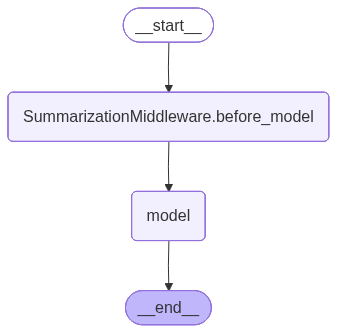

In [4]:
agent

In [5]:
config={"configurable":{"thread_id":"test_1"}}

In [6]:
question = [
    "what is 2+2?",
    "what is gen ai ?",
    "what is the meaning of life?",
    "what is the capital of France?",
    "what is the square root of 2?",
    "what is the square root of 2?",
    "what is the square root of 2?",
    "what is the square root of 2?",
    "what is the square root of 2?",
    "what is the square root of 2?",
]

for q in question:
    response = agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(response['messages'][-1].content)
    print(len(response['messages']))

2 + 2 = 4.
2
**Generative AI (Gen‑AI)** is a class of artificial‑intelligence systems that can create new content—text, images, audio, video, code, or even 3‑D models—rather than just analyzing or classifying existing data.

---

## 1. Core Idea
- **Learning from data:** A generative model is trained on large datasets (e.g., books, photos, code repositories) to learn the statistical patterns that underlie that data.
- **Generating “new” data:** After training, the model can produce novel outputs that resemble the training material but are not direct copies.

---

## 2. Main Technical Families

| Family | How it works (high‑level) | Typical outputs | Notable examples |
|--------|--------------------------|----------------|-------------------|
| **Transformer‑based language models** (e.g., GPT‑4, LLaMA, Claude) | Predict the next token (word/character) given a context; trained on massive text corpora. | Human‑like prose, code, summaries, chat replies. | OpenAI ChatGPT, Anthropic Claude, 

In [7]:
while True:
    query = input("Ask: ")
    if query == "exit":
        break
    response = agent.invoke({"messages":[HumanMessage(content=query)]},config)
    print(response['messages'][-1].content)

Nice to meet you, Sugumar! I’m ChatGPT, an AI language model created by OpenAI. How can I assist you today?
I was first made publicly available as **ChatGPT** in **November 2022** (based on the GPT‑3.5 model).  
Since then OpenAI has released newer versions—GPT‑4 in March 2023 and subsequent updates—so the service you’re interacting with today reflects those later improvements. If you meant something else by “when you came here,” just let me know!
I’m here to help you with a wide range of tasks, such as:

* **Answering questions** – factual info, explanations, “how‑to” guides, trivia, etc.  
* **Generating text** – essays, stories, emails, social‑media posts, poems, jokes, and more.  
* **Assisting with code** – writing, debugging, explaining programming concepts in many languages.  
* **Learning support** – tutoring in subjects like math, science, history, language learning, test‑prep tips.  
* **Creative brainstorming** – ideas for projects, recipes, travel itineraries, marketing slo